# Slow Dynamics and High Variability in Networks with Clustered Connections




In [2]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

from model import ClusterParams, ModelParams, NeuronNetwork, firing_rate

# Run and plot an un-clustered network

In [19]:
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=1.0)

unclustered_network = NeuronNetwork(params, cluster_params)
unclustered_network.run()

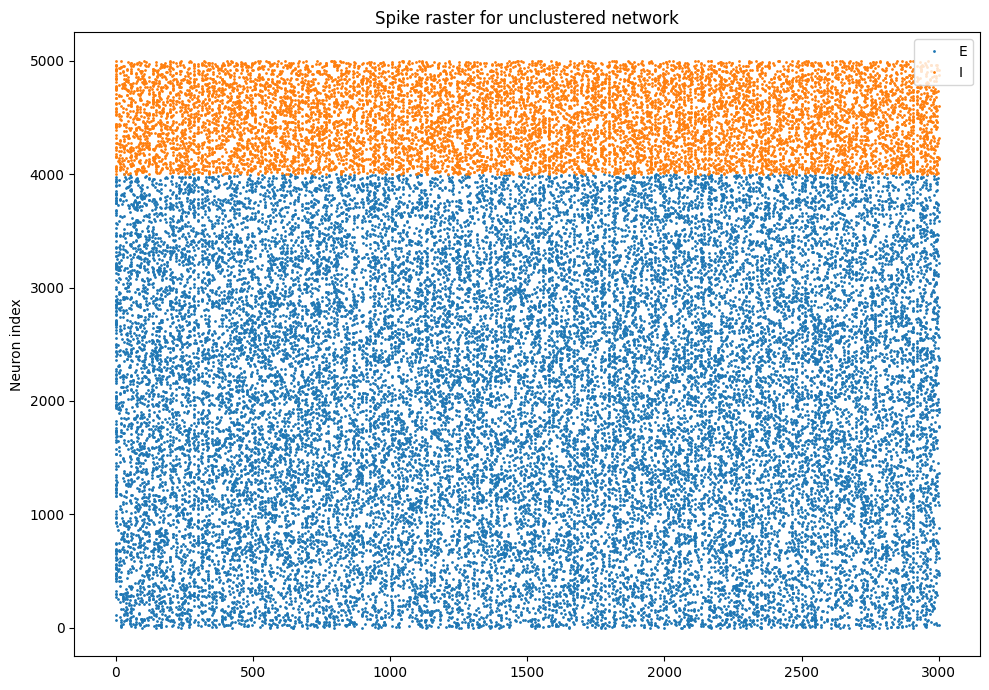

In [20]:
fig, axes = plt.subplots(figsize=(10, 7), sharex=True)

# Raster plot
axes.plot(unclustered_network.spike_monitor_e.t/ms, unclustered_network.spike_monitor_e.i, '.', markersize=2, label='E')
axes.plot(unclustered_network.spike_monitor_i.t/ms, unclustered_network.spike_monitor_i.i + params.N_E, '.', markersize=2, label='I')
axes.set_ylabel('Neuron index')
axes.set_title('Spike raster for unclustered network')
axes.legend(loc='upper right')

plt.tight_layout()
plt.show()

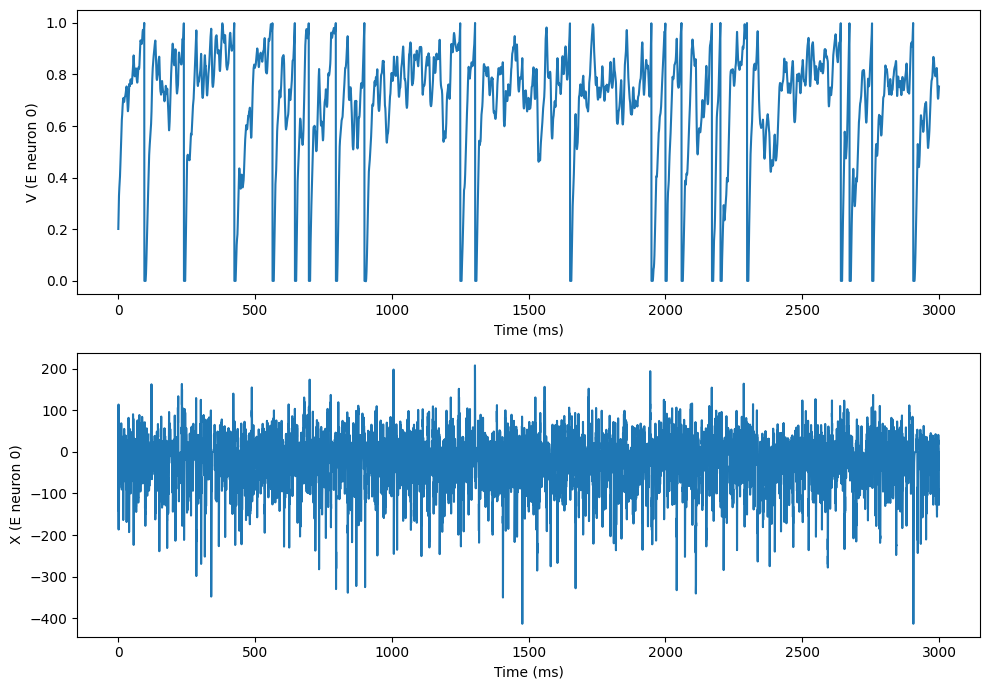

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(unclustered_network.state_monitor_e.t/ms, unclustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()

# Run and plot a clustered network

In [22]:
params = ModelParams()
cluster_params = ClusterParams(enabled=True, R_ee=2.5)

clustered_network = NeuronNetwork(params, cluster_params)
clustered_network.run()

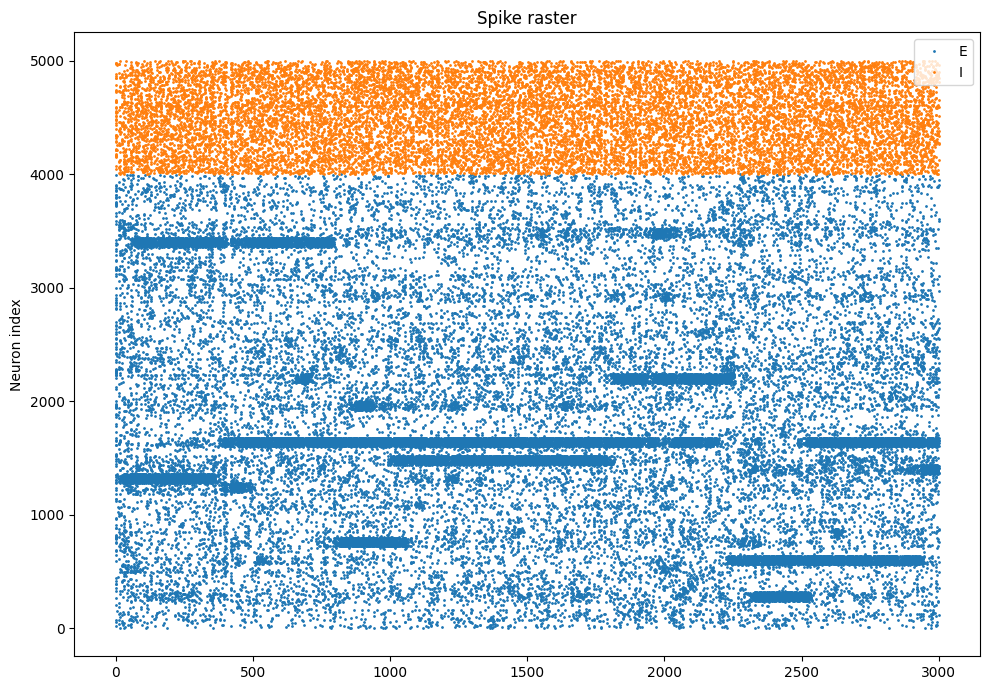

In [23]:
fig, axes = plt.subplots(figsize=(10, 7), sharex=True)

# Raster plot
axes.plot(clustered_network.spike_monitor_e.t/ms, clustered_network.spike_monitor_e.i, '.', markersize=2, label='E')
axes.plot(clustered_network.spike_monitor_i.t/ms, clustered_network.spike_monitor_i.i + params.N_E, '.', markersize=2, label='I')
axes.set_ylabel('Neuron index')
axes.set_title('Spike raster')
axes.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Plot the membrane potentials of a few neurons

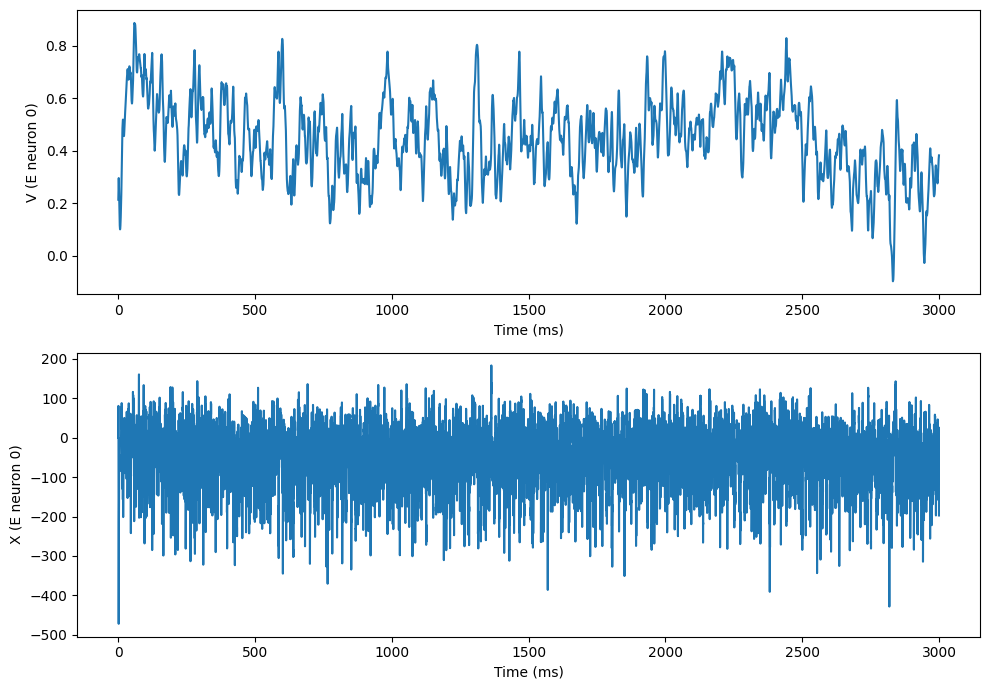

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

axes[0].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.V[0])
axes[0].set_ylabel('V (E neuron 0)')
axes[0].set_xlabel('Time (ms)')

axes[1].plot(clustered_network.state_monitor_e.t/ms, clustered_network.state_monitor_e.x[0])
axes[1].set_ylabel('X (E neuron 0)')
axes[1].set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()

# Plotting the firing rate distribution

(4000,) (1000,)
(5000,)
(4000,) (1000,)
(5000,)


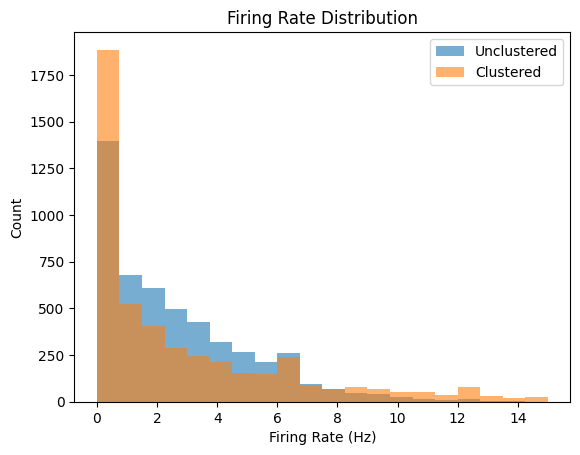

In [25]:
def plot_firing_rate_distribution(networks, labels, title, params):
    fig, ax = plt.subplots()

    firing_rates_by_label = {}
    for network, label in zip(networks, labels):
        firing_rates_e = firing_rate(
            network.spike_monitor_e,
            params.N_E,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        firing_rates_i = firing_rate(
            network.spike_monitor_i,
            params.N_I,
            params.analysis_start_t,
            params.analysis_window_t,
        )
        print(firing_rates_e.shape, firing_rates_i.shape)

        rates = np.concatenate([firing_rates_e, firing_rates_i])
        print(rates.shape)

        firing_rates_by_label[label] = rates
        ax.hist(
            rates,
            bins=20,
            range=(0, 15),
            alpha=0.6,
            label=label,
        )

    ax.set_xlabel('Firing Rate (Hz)')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.legend()

    return firing_rates_by_label

firing_rates_by_label = plot_firing_rate_distribution(
    [unclustered_network, clustered_network],
    ["Unclustered", "Clustered"],
    title="Firing Rate Distribution",
    params=params,
)

# Checking difference of exponential filter to an ODE

In [26]:
# TODO
# def x_prime(x, t1):
#     return -x / t1

# def g_prime(g, x, t2):
#     return (x - g) / t2

# def filter(t, t1, t2):
#     return 1 / (t2 - t1) * (np.exp(-t / t2) - np.exp(-t / t1))

# def euler_solve(x0, t, t1):
#     """Simple Euler method for x' = -x/t1."""
#     x = np.zeros_like(t)
#     x[0] = x0
#     dt = t[1] - t[0]
#     for i in range(1, len(t)):
#         x[i] = x[i - 1] + dt * x_prime(x[i - 1], t1)
#     return x

# t1 = 5.0
# x0 = 1.0
# t = np.linspace(0.0, 30.0, 600)

# x_num = euler_solve(x0, t, t1)

# sol = solve_ivp(
#     lambda tau, y: x_prime(y, t1),
#     t_span=(t[0], t[-1]),
#     y0=[x0],
#     t_eval=t,
# )
# x_scipy = sol.y[0]

# x_exact = x0 * np.exp(-t / t1)

# fig, ax = plt.subplots()
# ax.plot(t, x_num, label="Euler (numerical)")
# ax.plot(t, x_scipy, label="SciPy solve_ivp")
# ax.plot(t, x_exact, "--", label="Exact")
# ax.set_xlabel("t")
# ax.set_ylabel("x")
# ax.legend()
# plt.show()

# # Plot the filter for a sample t2.
# t2 = 2.0

# fig, ax = plt.subplots()
# ax.plot(t, filter(t, t1, t2), label="filter(t)")
# ax.set_xlabel("t")
# ax.set_ylabel("filter")
# ax.legend()
# plt.show()


    

# Experiment

Now instead of looking at a single network, we follow the paper's protocol of testing the uniform and clutered networks across 12 different network realizations, with 9 trials for each realization. This enables statistical analysis on spike counts.

# Correlation coefficients

In [12]:
seeds = np.random.randint(2,10000,1)
n_trials = 9

In [13]:
print(seeds)

[1282]


In [14]:
#Compute spike counts in sliding windows for all neurons at once (vectorized)
def window_spikes_all_neurons(spike_times, spike_ids, n_neurons, window, overlap, timerange):
    start_time = float(timerange[0])
    end_time = float(timerange[1])
    window = float(window)
    overlap = float(overlap)
    
    # Pre-compute all window start times
    window_starts = np.arange(start_time, end_time - window + overlap, overlap)
    n_windows = len(window_starts)
    
    # Initialize output array
    window_counts = np.zeros((n_neurons, n_windows), dtype=np.int32)
    
    # Convert spike times to float array for fast comparison
    spike_times = np.asarray(spike_times)
    spike_ids = np.asarray(spike_ids)
    
    # For each window, count spikes per neuron using bincount
    for w, ws in enumerate(window_starts):
        mask = (spike_times >= ws) & (spike_times < ws + window)
        window_counts[:, w] = np.bincount(spike_ids[mask], minlength=n_neurons)
    
    return window_counts

#Calculates variance and covariance for all neurons (optimized)
def calc_var_cov(network, params, window, overlap, timerange):
    spike_times = network.spike_monitor_e.t
    spike_ids = network.spike_monitor_e.i
    
    window_counts = window_spikes_all_neurons(
        spike_times, spike_ids, params.N_E, window, overlap, timerange
    )
    
    cov_matrix = np.cov(window_counts, rowvar=True, bias=False)
    row_vars = np.var(window_counts, axis=1, ddof=1)
    
    return cov_matrix, row_vars

#Calculates the correlation coefficients
def calc_coeffs(cov_matrix, neuron_vars, params):
    coeffs = []
    for i in range(params.N_E):
        for j in range(i+1,params.N_E):
            coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
    
    return np.array(coeffs)

#Function to calculate same cluster coefficients
def calc_cluster_coeffs(cov_matrix, neuron_vars, params, cluster_params):
    coeffs = []
    n_cluster = cluster_params.cluster_size
    for i in range(params.N_E):
        j_same_cluster = (i // n_cluster)*n_cluster + n_cluster
        for j in range(i+1,j_same_cluster):
            coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
    
    return np.array(coeffs)

#Loads covariance/variance data from saved files and computes a mean based on them
def load_and_mean(seeds, n_trials, path_str):
    total_trials = len(seeds)*n_trials

    tot_cov = []
    tot_var = []
    for seed in seeds:
        for trial in range(n_trials):
            data = np.load(f"{path_str}{seed}_{trial}.npz")
            cov_matrix = data["a"]
            row_vars = data["b"]

            if len(tot_cov) == 0: tot_cov = cov_matrix
            else: tot_cov += cov_matrix

            if len(tot_var) == 0: tot_var = row_vars
            else: tot_var += row_vars

    mean_cov = tot_cov / total_trials
    mean_var = tot_var / total_trials

    return mean_cov, mean_var

#Runs len(seeds)*n_trials runs --> calculates covariance/variance --> saves results to files
def run_corr_experiments(seeds, n_trials, params, cluster_params, window, overlap, timerange, path_str=""):
    for seed in seeds:
        network = NeuronNetwork(params, cluster_params, seed=seed)
        print(f"Using seed: {seed}")

        for trial in range(n_trials):
            print(f"Trial: {trial}")
            network.run()

            cov_matrix, row_vars = calc_var_cov(network, params, window, overlap, timerange)

            #Currently saves each trial into a file, which can be used later to retrieve the values in calculating the mean. I do it, because my computer ran out of memory.
            #TODO: Maybe the memory issue could be dealt with in a different manner
            np.savez(f"{path_str}{seed}_{trial}.npz", a=cov_matrix, b=row_vars)

#Function to plot the histograms
def plot_corr_experiments(ax, bins, uniform, cluster, exponent, xlabel):
    ax.hist(uniform, bins=bins, histtype="step", linewidth=2, color="black", label="Uniform network")
    ax.hist(cluster, bins=bins, histtype="step", linewidth=2, color="limegreen", label="Clustered network")  # optional overlay

    ax.set_xlim(np.min(bins), np.max(bins))
    ax.set_xlabel(xlabel)

    #Show y in scientific notation like ×10^6
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((exponent, exponent))  # try to force 10^6; tweak as needed
    ax.yaxis.set_major_formatter(fmt)

    #Mean marker (downward triangle at the top)
    y_top = ax.get_ylim()[1]
    m = np.mean(uniform)
    ax.plot([m], [y_top*1.01], marker="v", markersize=6, color="black", clip_on=False)
    m_cluster = np.mean(cluster)
    ax.plot([m_cluster], [y_top*1.01], marker="v", markersize=6, color="limegreen", clip_on=False)

In [15]:
#Constants

window = 50*ms #Window size
overlap = 2*ms #Window overlap size
timerange = (1.5*second, 3*second) #Time range for windows

In [16]:
#Unclustered network - running experiments

#Runs for approx 100 minutes for 12*9 trials, N_E=4000 and N_I=1000
params = ModelParams(N_E=4000, N_I=1000)
cluster_params = ClusterParams(enabled=True, R_ee=1.0)
run_corr_experiments(seeds, n_trials, params, cluster_params, window, overlap, timerange, path_str="saved_runs/")

Using seed: 1282
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4
Trial: 5
Trial: 6
Trial: 7
Trial: 8


In [17]:
#Clustered network - running experiments

#Runs for approx 100 minutes for 12*9 trials, N_E=4000 and N_I=1000
params = ModelParams(N_E=4000, N_I=1000)
cluster_params = ClusterParams(enabled=True, R_ee=2.5)
run_corr_experiments(seeds, n_trials, params, cluster_params, window, overlap, timerange, path_str="saved_runs/clustered_")

Using seed: 1282
Trial: 0
Trial: 1
Trial: 2
Trial: 3
Trial: 4
Trial: 5
Trial: 6
Trial: 7
Trial: 8


In [18]:
#Now loads in the saved files and computes the mean covariance/variance
mean_cov_uniform, mean_var_uniform = load_and_mean(seeds, n_trials, "saved_runs/")
mean_cov_clustered, mean_var_clustered = load_and_mean(seeds, n_trials, "saved_runs/clustered_")

In [19]:
#Calculates coefficients for the uniform and clustered experiments
uniform_coeffs = calc_coeffs(mean_cov_uniform, mean_var_uniform, params)
uniform_same_cluster_coeffs = calc_cluster_coeffs(mean_cov_uniform, mean_var_uniform, params, cluster_params)

clustered_coeffs = calc_coeffs(mean_cov_clustered, mean_var_clustered, params)
clustered_same_cluster_coeffs = calc_cluster_coeffs(mean_cov_clustered, mean_var_clustered, params, cluster_params)

WARNING    /var/folders/_f/t5z2mynd5cg523nhd8bwyj980000gn/T/ipykernel_66968/2618790149.py:45: RuntimeWarning: invalid value encountered in scalar divide
  coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
 [py.warnings]
WARNING    /var/folders/_f/t5z2mynd5cg523nhd8bwyj980000gn/T/ipykernel_66968/2618790149.py:56: RuntimeWarning: invalid value encountered in scalar divide
  coeffs.append(cov_matrix[i][j] / np.sqrt(neuron_vars[i] * neuron_vars[j]))
 [py.warnings]


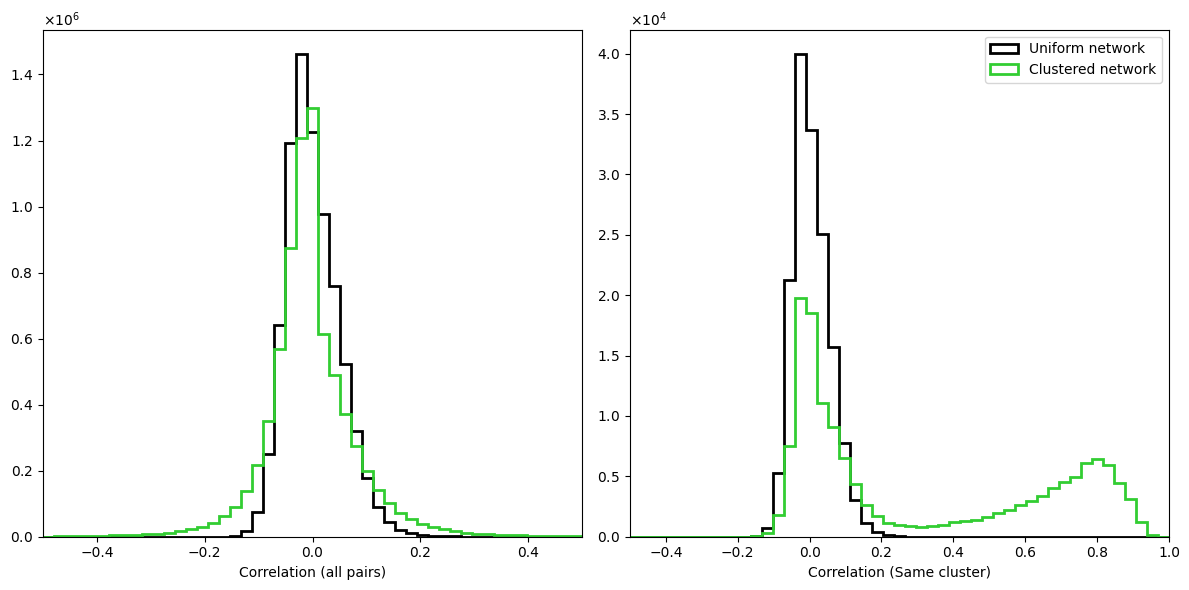

In [20]:
#plot step histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

bins1 = np.linspace(-0.5, 0.5, 50)
plot_corr_experiments(axes[0], bins1, uniform_coeffs, clustered_coeffs, 6, "Correlation (all pairs)")

bins2 = np.linspace(-0.5, 1, 50)
plot_corr_experiments(axes[1], bins2, uniform_same_cluster_coeffs, clustered_same_cluster_coeffs, 4, "Correlation (Same cluster)")

plt.legend()
plt.tight_layout()
plt.show()